12:35:43  ============================================================
12:35:43    ACF & PACF ANALYSIS — ml_mart.base (LOCAL DVC)
12:35:43  ============================================================
12:35:43  [LOAD] Chọn file Parquet từ DVC local cache...
12:35:46    File: D:/DATN/datn_outlier_hs_nlmt/data/mlmart_base/ml_mart_base_data.parquet
12:35:49    Tổng số dòng: 2,731,946  |  Cột: ['gen_id', 'site_id', 'geo_id', 'date_id', 'time_id', 'timestamp', 'is_dst_repeat', 'full_date', 'year', 'month', 'day', 'day_of_week', 'hour', 'minute', 'energy_generated_kwh', 'rolling_outlier_flag', 'campus_name', 'capacity_kw', 'number_of_panels', 'panel', 'inverter', 'optimizers', 'site_metric', 'location_name', 'latitude', 'longitude', 'weather_id', 'weather_type_id', 'weather_timestamp', 'weather_is_day', 'shortwave_radiation', 'direct_normal_irradiance', 'diffuse_solar_radiation', 'temperature_c', 'cloud_cover_total', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_speed', 'pr

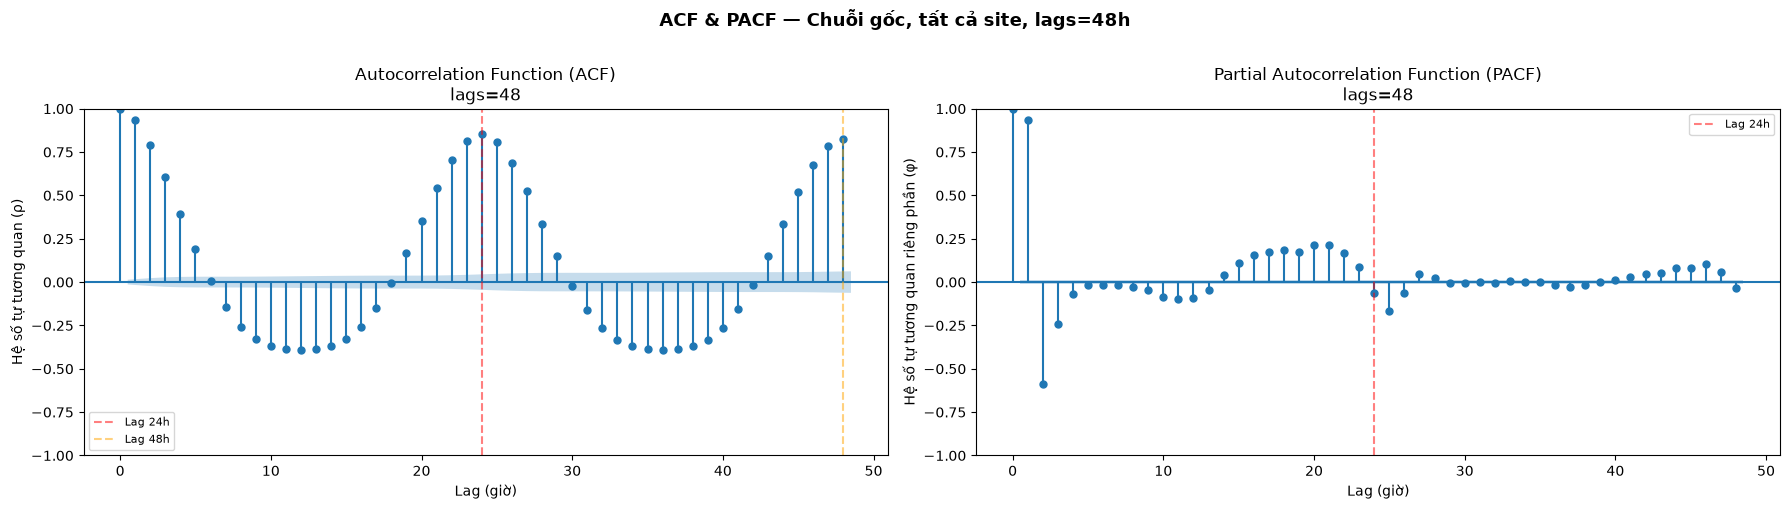

12:36:24    Đã lưu: ..\reports\figures\acf_pacf_output\acf_pacf_01_raw_48lags.png
12:36:24  
[Case 2] ACF/PACF — Chuỗi gốc, lags=168 (1 tuần)


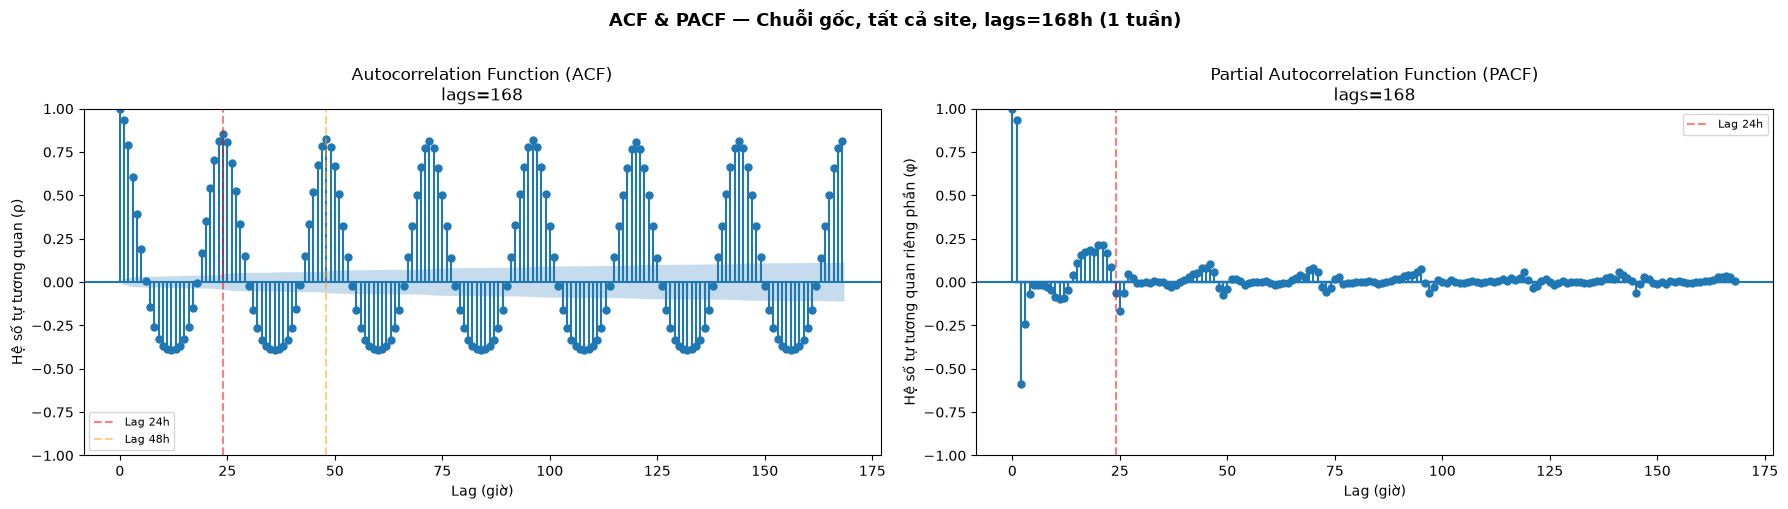

12:36:33    Đã lưu: ..\reports\figures\acf_pacf_output\acf_pacf_02_raw_168lags.png
12:36:33  
[Case 3] Chuỗi đã dừng — bỏ qua sai phân
12:36:33  
[Case 4] ACF/PACF — Chỉ giờ ban ngày (6h–18h)
12:36:46    ADF Test [ban ngày]: p-value = 0.000000  →  DỪNG ✅


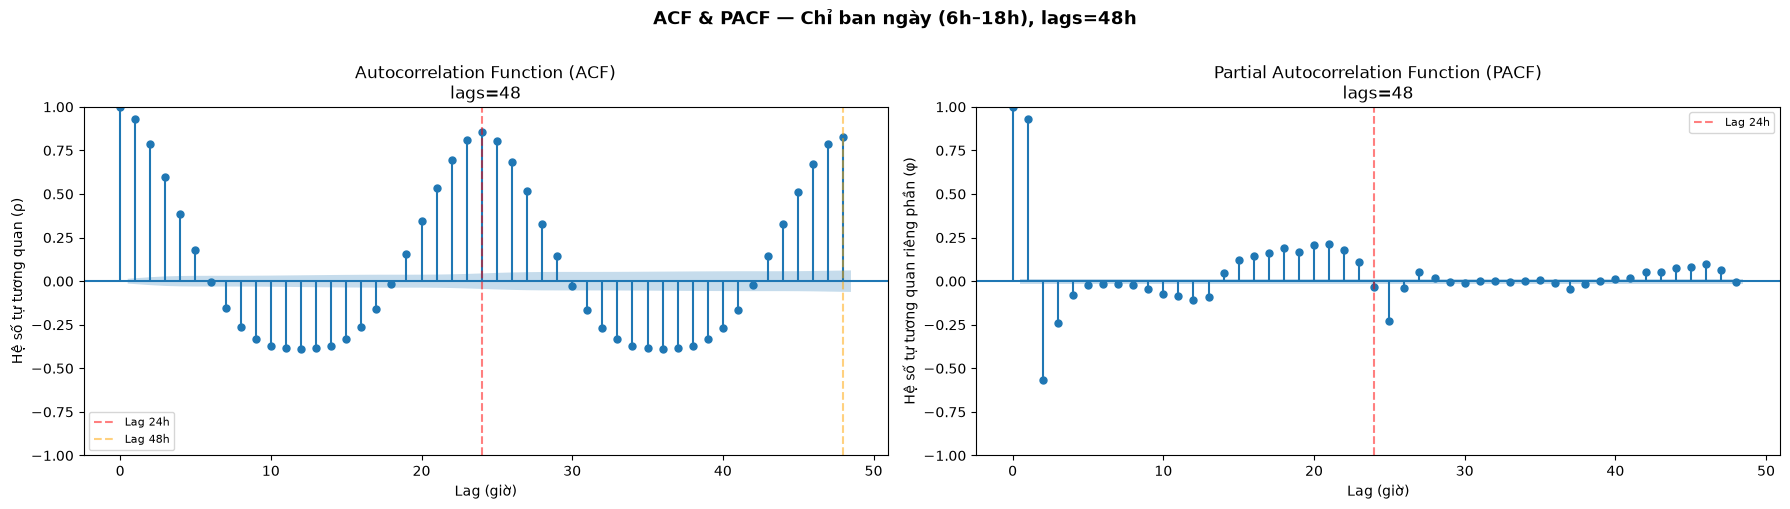

12:36:49    Đã lưu: ..\reports\figures\acf_pacf_output\acf_pacf_04_daytime_48lags.png
12:36:49  
────────────────────────────────────────────────────────────
12:36:49    HƯỚNG DẪN ĐỌC KẾT QUẢ
12:36:49  ────────────────────────────────────────────────────────────
12:36:49    ACF  → đếm lag vượt dải xanh ở đầu  → chốt q (MA)
12:36:49    PACF → đếm lag vượt dải xanh ở đầu  → chốt p (AR)
12:36:49    Spike tại lag=24, 48 → chu kỳ ngày/đêm (Seasonal 24h)
12:36:49    Nếu ACF giảm chậm (tail-off) → chuỗi chưa dừng, cần d≥1
12:36:49  ────────────────────────────────────────────────────────────
12:36:49    Kết quả lưu tại: ..\reports\figures\acf_pacf_output/
12:36:49  ============================================================


In [2]:
"""
acf_pacf_analysis.py - Vẽ biểu đồ ACF và PACF cho chuỗi thời gian sản lượng điện
Cài: pip install pandas matplotlib statsmodels pyarrow
"""

import logging
import os
from tkinter import Tk, filedialog

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger()

OUTPUT_DIR = os.path.join("..", "reports", "figures", "acf_pacf_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ─── Browse file ──────────────────────────────────────────────
def browse_file(title: str) -> str:
    root = Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    path = filedialog.askopenfilename(
        title=title,
        filetypes=[
            ("Parquet files", "*.parquet"),
            ("CSV files", "*.csv"),
            ("All files", "*.*"),
        ]
    )
    root.destroy()
    if not path:
        raise FileNotFoundError(f"Không có file nào được chọn: {title}")
    return path


# ─── Load file (parquet hoặc csv) ────────────────────────────
def load_data(path: str) -> pd.DataFrame:
    if path.endswith(".parquet"):
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path, dtype=str, on_bad_lines="skip")
        df.columns = df.columns.str.strip()
    log.info(f"  Tổng số dòng: {len(df):,}  |  Cột: {list(df.columns)}")
    return df


# ─── Chuẩn bị chuỗi thời gian hourly ────────────────────────
def prepare_hourly_series(df: pd.DataFrame, site_id: int = None) -> pd.Series:
    """
    Tổng hợp energy_generated_kwh theo giờ từ ml_mart.base.
    Nếu site_id được truyền vào thì lọc theo 1 site cụ thể.
    Trả về pd.Series với DatetimeIndex.
    """
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["energy_generated_kwh"] = pd.to_numeric(df["energy_generated_kwh"], errors="coerce")
    df["rolling_outlier_flag"] = df["rolling_outlier_flag"].astype(str).str.lower().map(
        {"true": True, "false": False, "1": True, "0": False}
    )

    # Lọc outlier và ban đêm
    mask = (df["rolling_outlier_flag"] != True)
    if site_id is not None:
        df["site_id"] = pd.to_numeric(df["site_id"], errors="coerce")
        mask = mask & (df["site_id"] == site_id)
        log.info(f"  Lọc theo site_id = {site_id}")

    df_clean = df[mask].copy()

    # Group by timestamp (hourly)
    df_clean = df_clean.set_index("timestamp").sort_index()
    hourly = df_clean["energy_generated_kwh"].resample("h").sum()

    # Điền NaN bằng 0 cho giờ ban đêm
    hourly = hourly.fillna(0)

    log.info(f"  Chuỗi hourly: {len(hourly):,} điểm  |  {hourly.index[0]} → {hourly.index[-1]}")
    return hourly


# ─── Kiểm định tính dừng ADF ──────────────────────────────────
def check_stationarity(series: pd.Series, name: str) -> bool:
    result = adfuller(series.dropna(), autolag="AIC")
    p_value = result[1]
    is_stationary = p_value < 0.05
    status = "DỪNG ✅" if is_stationary else "KHÔNG DỪNG ❌"
    log.info(f"  ADF Test [{name}]: p-value = {p_value:.6f}  →  {status}")
    return is_stationary


# ─── Vẽ ACF + PACF ───────────────────────────────────────────
def plot_acf_pacf(series: pd.Series, lags: int, title_suffix: str, filename: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f"ACF & PACF — {title_suffix}", fontsize=13, fontweight="bold", y=1.01)

    plot_acf(
        series.dropna(),
        lags=lags,
        ax=axes[0],
        title=f"Autocorrelation Function (ACF)\nlags={lags}",
        alpha=0.05,
    )
    axes[0].set_xlabel("Lag (giờ)", fontsize=10)
    axes[0].set_ylabel("Hệ số tự tương quan (ρ)", fontsize=10)
    axes[0].axvline(x=24, color="red", linestyle="--", alpha=0.5, label="Lag 24h")
    axes[0].axvline(x=48, color="orange", linestyle="--", alpha=0.5, label="Lag 48h")
    axes[0].legend(fontsize=8)

    plot_pacf(
        series.dropna(),
        lags=lags,
        ax=axes[1],
        title=f"Partial Autocorrelation Function (PACF)\nlags={lags}",
        alpha=0.05,
        method="ywm",
    )
    axes[1].set_xlabel("Lag (giờ)", fontsize=10)
    axes[1].set_ylabel("Hệ số tự tương quan riêng phần (φ)", fontsize=10)
    axes[1].axvline(x=24, color="red", linestyle="--", alpha=0.5, label="Lag 24h")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    log.info(f"  Đã lưu: {path}")


# ─── Main ─────────────────────────────────────────────────────
def main() -> None:
    log.info("=" * 60)
    log.info("  ACF & PACF ANALYSIS — ml_mart.base (LOCAL DVC)")
    log.info("=" * 60)

    # 1. Load file
    log.info("[LOAD] Chọn file Parquet từ DVC local cache...")
    path = browse_file("Chọn file ml_mart base (parquet hoặc csv)")
    log.info(f"  File: {path}")
    df = load_data(path)

    # 2. Chuẩn bị chuỗi — toàn bộ data (tất cả site)
    log.info("\n[PREP] Chuẩn bị chuỗi hourly (tất cả site)...")
    hourly_all = prepare_hourly_series(df, site_id=None)

    # ── Case 1: ACF/PACF chuỗi gốc, lags=48 (2 ngày) ────────
    log.info("\n[Case 1] ACF/PACF — Chuỗi gốc, lags=48 (2 ngày)")
    is_stat = check_stationarity(hourly_all, "chuỗi gốc")
    plot_acf_pacf(
        hourly_all,
        lags=48,
        title_suffix="Chuỗi gốc, tất cả site, lags=48h",
        filename="acf_pacf_01_raw_48lags.png",
    )

    # ── Case 2: ACF/PACF chuỗi gốc, lags=168 (1 tuần) ───────
    log.info("\n[Case 2] ACF/PACF — Chuỗi gốc, lags=168 (1 tuần)")
    plot_acf_pacf(
        hourly_all,
        lags=168,
        title_suffix="Chuỗi gốc, tất cả site, lags=168h (1 tuần)",
        filename="acf_pacf_02_raw_168lags.png",
    )

    # ── Case 3: Differencing nếu chuỗi không dừng ───────────
    if not is_stat:
        log.info("\n[Case 3] Chuỗi không dừng → Sai phân bậc 1 (d=1)...")
        hourly_diff = hourly_all.diff().dropna()
        check_stationarity(hourly_diff, "chuỗi sau sai phân bậc 1")
        plot_acf_pacf(
            hourly_diff,
            lags=48,
            title_suffix="Sau sai phân bậc 1 (d=1), lags=48h",
            filename="acf_pacf_03_diff1_48lags.png",
        )
    else:
        log.info("\n[Case 3] Chuỗi đã dừng — bỏ qua sai phân")

    # ── Case 4: Chỉ ban ngày (6h–18h) — loại nhiễu ban đêm ──
    log.info("\n[Case 4] ACF/PACF — Chỉ giờ ban ngày (6h–18h)")
    df["hour"] = pd.to_numeric(df.get("hour", pd.Series(dtype=float)), errors="coerce")
    if "hour" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df["energy_generated_kwh"] = pd.to_numeric(df["energy_generated_kwh"], errors="coerce")
        mask_day = (
            (df["rolling_outlier_flag"].astype(str).str.lower() != "true") &
            (df["hour"] >= 6) & (df["hour"] <= 18)
        )
        df_day = df[mask_day].copy()
        df_day = df_day.set_index("timestamp").sort_index()
        hourly_day = df_day["energy_generated_kwh"].resample("h").sum().fillna(0)

        check_stationarity(hourly_day, "ban ngày")
        plot_acf_pacf(
            hourly_day,
            lags=48,
            title_suffix="Chỉ ban ngày (6h–18h), lags=48h",
            filename="acf_pacf_04_daytime_48lags.png",
        )
    else:
        log.info("  Không tìm thấy cột hour — bỏ qua Case 4")

    # ── Tóm tắt đọc kết quả ──────────────────────────────────
    log.info("\n" + "─" * 60)
    log.info("  HƯỚNG DẪN ĐỌC KẾT QUẢ")
    log.info("─" * 60)
    log.info("  ACF  → đếm lag vượt dải xanh ở đầu  → chốt q (MA)")
    log.info("  PACF → đếm lag vượt dải xanh ở đầu  → chốt p (AR)")
    log.info("  Spike tại lag=24, 48 → chu kỳ ngày/đêm (Seasonal 24h)")
    log.info("  Nếu ACF giảm chậm (tail-off) → chuỗi chưa dừng, cần d≥1")
    log.info("─" * 60)
    log.info(f"  Kết quả lưu tại: {OUTPUT_DIR}/")
    log.info("=" * 60)


if __name__ == "__main__":
    main()